# 7 · Inspecting & Cleaning Data
*Intro to Python for Scientists & Public Health Professionals*

Real data arrives messy: wrong types, duplicate rows, missing values, sentinel codes like `?`, inconsistent categories, and outliers. This lesson is the workflow for turning a raw load into something analysis-ready, using the same diabetes dataset we first met in the pandas intro.

A note on plots: we use a handful of quick charts here purely to *guide cleaning decisions*. Producing polished, publication-quality visuals is the focus of the separate Data Visualization course.

### By the end of this notebook you can
- Inspect a dataset (`head`, `info`, `describe`)
- Remove duplicates and fix data types
- Find and handle missing data, including sentinel values
- Standardize messy categorical values
- Spot and remove outliers, and drop columns/rows you don't need

### Agenda
1. First look
2. Duplicates
3. Data types
4. Renaming columns
5. Missing data
6. Imputing
7. Fixing categorical values
8. Distributions & outliers
9. Dropping columns & rows

### How the exercises work
Each exercise has a prompt, an empty cell to try it yourself, and a collapsed **Solution** you can expand to check your work.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_URL = "https://raw.githubusercontent.com/jimcody2014/2026-python-data/refs/heads/main"
df = pd.read_csv(f"{BASE_URL}/diabetes_inspect.csv")
df.shape

(101767, 33)

## 1. First look

Three quick views before touching anything: the first rows, the column/dtype summary, and numeric summary stats.

In [8]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,glipizide,glyburide,tolbutamide,miglitol,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,xyz,?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,NaN,?,1,1,7,3,...,No,No,No,No,Up,No,No,No,Yes,>30
2,64410,86047875,AfricanAmerican,female,[20-30),?,1,1,7,2,...,Steady,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Mle,[30-40),?,1,1,7,2,...,No,No,No,No,Up,No,No,No,Yes,NO
4,16680,42519267,Caucasian,M,[40-50),?,1,1,7,1,...,Steady,No,No,No,Steady,No,No,No,Yes,NO


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101767 entries, 0 to 101766
Data columns (total 33 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   encounter_id              101767 non-null  int64  
 1   patient_nbr               101767 non-null  int64  
 2   race                      101767 non-null  object 
 3   gender                    101767 non-null  object 
 4   age                       101766 non-null  object 
 5   weight                    101767 non-null  object 
 6   admission_type_id         101767 non-null  int64  
 7   discharge_disposition_id  101767 non-null  int64  
 8   admission_source_id       101767 non-null  int64  
 9   time_in_hospital          101767 non-null  int64  
 10  payer_code                101767 non-null  object 
 11  medical_specialty         101767 non-null  object 
 12  num_lab_procedures        101767 non-null  int64  
 13  num_procedures            101767 non-null  i

In [10]:
df.describe()    # summary stats for the numeric columns

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient
count,1.017670e+05,1.017670e+05,101767.000000,101767.000000,101767.000000,101767.000000,101767.000000,101767.000000,101758.000000,101767.000000,101767.000000,101767.000000
mean,1.652044e+08,5.433159e+07,2.023996,3.715615,5.754449,4.396003,43.095345,1.339747,16.021836,0.369354,0.197834,0.635560
std,1.026435e+08,3.869803e+07,1.445399,5.280146,4.064063,2.985097,19.674492,1.705807,8.127926,1.267259,0.930468,1.262859
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,8.496232e+07,2.341323e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000
50%,1.523897e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000
75%,2.302720e+08,8.754619e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000


## 2. Duplicates

In [11]:
df.duplicated().sum()    # how many fully-duplicated rows are there?

np.int64(1)

In [12]:
df = df.drop_duplicates()   # keeps the FIRST occurrence of each duplicate by default
df.duplicated().sum()

np.int64(0)

## 3. Data types

IDs are stored as integers, but they are **labels, not quantities** — you'd never take their mean. Store them as text so they aren't treated as numbers.

In [13]:
id_cols = ["encounter_id", "patient_nbr", "admission_type_id",
           "discharge_disposition_id", "admission_source_id"]
df[id_cols] = df[id_cols].astype("string")
df[id_cols].dtypes

encounter_id                string[python]
patient_nbr                 string[python]
admission_type_id           string[python]
discharge_disposition_id    string[python]
admission_source_id         string[python]
dtype: object

## 4. Renaming columns

Shorten a few unwieldy names (assign the result back — the modern idiom).

In [14]:
df = df.rename(columns={
    "admission_type_id": "admit_type",
    "discharge_disposition_id": "discharge_dispo",
    "admission_source_id": "admit_source",
    "num_lab_procedures": "lab_procedures",
    "num_procedures": "procedures",
})
df.columns.tolist()[:10]

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admit_type',
 'discharge_dispo',
 'admit_source',
 'time_in_hospital']

## 5. Missing data

Start by quantifying it: what fraction of each column is missing?

In [15]:
missing_pct = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_pct.head(8)

max_glu_serum               94.7
A1Cresult                   83.3
encounter_id                 0.0
number_inpatient             0.0
diabetesMed                  0.0
glimepiride-pioglitazone     0.0
glipizide-metformin          0.0
glyburide-metformin          0.0
dtype: float64

Watch for **sentinel values** — this dataset uses `?` to mean missing. Those aren't counted as missing until you convert them to real `NaN`.

In [16]:
(df == "?").sum().sort_values(ascending=False).head()

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_1                  21
dtype: Int64

In [17]:
df = df.replace("?", pd.NA)
missing_pct = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_pct.head(8)

weight               96.9
max_glu_serum        94.7
A1Cresult            83.3
medical_specialty    49.1
payer_code           39.6
race                  2.2
metformin             0.0
glimepiride           0.0
dtype: float64

A quick chart makes the picture obvious — which columns are mostly empty versus mostly complete.

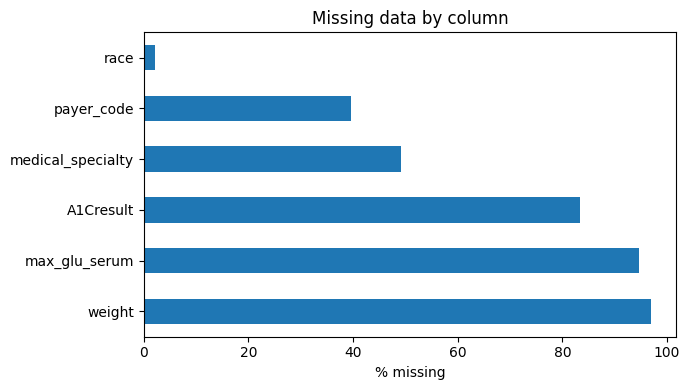

In [18]:
ax = missing_pct[missing_pct > 0].plot.barh(figsize=(7, 4))
ax.set_xlabel("% missing")
ax.set_title("Missing data by column")
plt.tight_layout(); plt.show()

## 6. Imputing

For a numeric column with a little missingness, filling with the **median** is a robust default (less sensitive to skew than the mean).

In [19]:
df["num_medications"] = df["num_medications"].fillna(df["num_medications"].median())
df["num_medications"].isna().sum()

np.int64(0)

> Other options: `mean()`, a fixed constant, or — for ordered/time data — carry values forward/backward with `df.ffill()` / `df.bfill()`. (Note: the old `fillna(method='ffill')` and chained `fillna(..., inplace=True)` forms are deprecated/removed in modern pandas; assign the result back instead.)

## 7. Fixing categorical values

Inspect a category's values with `value_counts`, then standardize. Use vectorized string methods (`.str.lower()`), which skip `NaN` safely — unlike `apply(lambda x: x.lower())`, which errors on missing values.

In [20]:
df["gender"].value_counts(dropna=False)

gender
Female             54706
Male               47051
Unknown/Invalid        3
female                 1
Mle                    1
M                      1
male                   1
F                      1
<NA>                   1
Name: count, dtype: int64

In [ ]:
#This is method chaining
df["gender"] = df["gender"].str.strip().str.lower()
# df["gender"] grabs the entire gender column from the data frame
# str - .str means do a text operation on every value in this column
# .strip() removes spaces and tabs from the beginning and end
# .str - same
# .lower() convert all values to lowercase
df["gender"] = df["gender"].replace({"m": "male", "f": "female", "mle": "male",
                                     "unknown/invalid": pd.NA})
df["gender"].value_counts(dropna=False)

gender
female    54708
male      47054
<NA>          4
Name: count, dtype: int64

> A data-quality principle: map genuinely unknown values (`unknown/invalid`) to **missing**, not to a guessed category. Don't fabricate data while cleaning it.

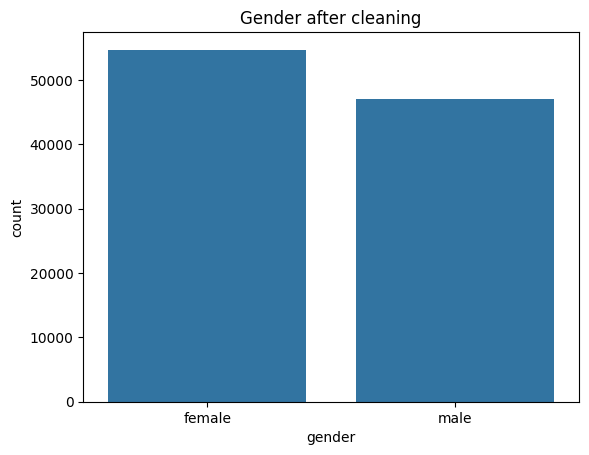

In [22]:
sns.countplot(x="gender", data=df)
plt.title("Gender after cleaning"); plt.show()

### The `.str` accessor

`.str` is how you do string work on entire columns in pandas — transforming text, or flagging and counting rows that match a pattern.

Vectorized string methods operate on a whole text column at once — the core toolkit for messy categorical and text data. A few of the most useful:

In [23]:
# df["race"].str.upper().head(3).tolist()              # transform every value
# df["race"].str.contains("Afr", na=False).sum()       # rows whose race contains 'Afr'
# df["diag_1"].str.startswith("250", na=False).sum()   # primary diabetes dx (ICD-9 250.x)

> `.str` also covers `.split()`, `.replace()`, `.strip()`, and `.extract()` (with a regex) — everything you need to pull apart and standardize text. [Working with text data](https://pandas.pydata.org/docs/user_guide/text.html).

## 8. Distributions & outliers

A histogram shows a numeric column's shape; a boxplot makes outliers visible.

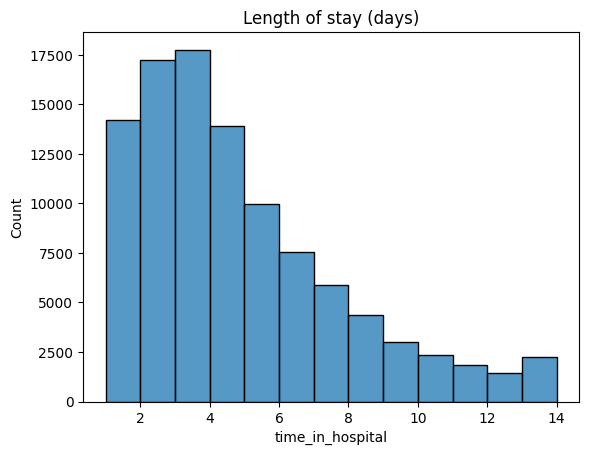

In [24]:
sns.histplot(data=df, x="time_in_hospital", binwidth=1)
plt.title("Length of stay (days)"); plt.show()

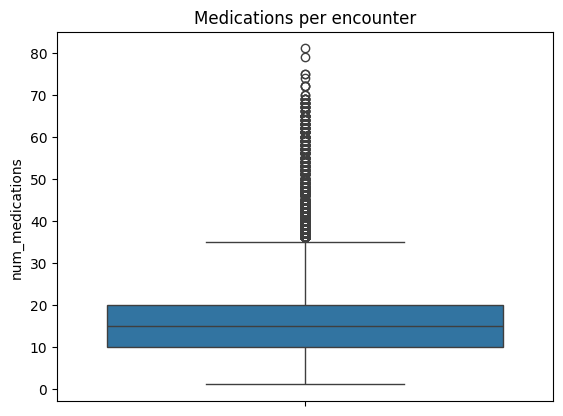

In [25]:
sns.boxplot(data=df, y="num_medications")
plt.title("Medications per encounter"); plt.show()

A common, defensible rule for flagging outliers is the **1.5 × IQR** rule (the same rule a boxplot's whiskers use).

In [26]:
q1, q3 = df["num_medications"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
print(f"keep rows with num_medications in [{low:.0f}, {high:.0f}]")

before = len(df)
df = df[df["num_medications"].between(low, high)]
print("removed", before - len(df), "outlier rows")

keep rows with num_medications in [-5, 35]
removed 2557 outlier rows


### Correlations

A quick numeric scan of how the numeric columns move together — no plot required. `numeric_only=True` is needed because the frame still has text columns.

In [27]:
df.corr(numeric_only=True).round(2)

,time_in_hospital,lab_procedures,procedures,num_medications,number_outpatient,number_emergency,number_inpatient
time_in_hospital,1.00,0.30,0.14,0.43,-0.01,-0.01,0.08
lab_procedures,0.30,1.00,0.02,0.24,-0.01,-0.00,0.04
procedures,0.14,0.02,1.00,0.30,-0.02,-0.03,-0.06
num_medications,0.43,0.24,0.30,1.00,0.06,0.03,0.09
number_outpatient,-0.01,-0.01,-0.02,0.06,1.00,0.09,0.11
number_emergency,-0.01,-0.00,-0.03,0.03,0.09,1.00,0.27
number_inpatient,0.08,0.04,-0.06,0.09,0.11,0.27,1.00


> Values near +1 or −1 mean a strong linear relationship; near 0, little. (Rendering this as a heatmap is covered in the Data Visualization course.)

## 9. Dropping columns & rows

In [28]:
# Drop columns that are mostly empty or not useful for analysis
df = df.drop(columns=["weight", "payer_code", "max_glu_serum"])
df.shape

(99209, 30)

In [29]:
# Drop rows with an invalid 'age' sentinel we saw in the first look
df = df[df["age"] != "xyz"]
df.shape

(99208, 30)

### Exercise — Finish the cleaning *(12 min)*

Working on the current `df`:
1. After the `?` → `NaN` fix, how many rows are missing `race`?
2. Compute the percentage of `A1Cresult` that is missing. If it exceeds 35%, drop the column.
3. Report the final shape.

In [30]:
# Your work here


### Exercise 2 — Capstone Part 2

Open your **Rural Hospital Closures capstone** and complete **Part 1 (Cleaning)**: Complete the 12 tasks.

## Wrap-up

You can inspect a dataset, remove duplicates, fix types, quantify and handle missing data (including sentinels), standardize categories, and deal with outliers — the core of getting data analysis-ready.

**Next:** Feature engineering & GroupBy — building new columns and summarizing by group.